In [ ]:
# The following installation code are for libraries not already provided
!poetry add vaderSentiment
!poetry add "spacy>=3.8.0,<4.0.0" --python "<3.15"
!poetry run python -m spacy download en_core_web_sm


Updating dependencies
Resolving dependencies...

No dependencies to install or update


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.8 MB 20.2 MB/s eta 0:00:01
     ---------------------- ----------------- 7.1/12.8 MB 21.8 MB/s eta 0:00:01
     ------------------------------------- - 12.3/12.8 MB 23.4 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 21.1 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import itertools
from collections import Counter

from scipy.stats import spearmanr, skew
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stopwords = set(stopwords.words('english'))

import spacy
nlp = spacy.load('en_core_web_sm')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\spher\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [132]:
# Import evaluation data on responses
eval_gain = pd.read_csv('evaluation_outputs_gain.csv')
eval_loss = pd.read_csv('evaluation_outputs_loss.csv')

# Import training data on responses
train_gain = pd.read_csv('instruction_responses.csv')[['policy', 'gain_response']]
train_loss = pd.read_csv('instruction_responses.csv')[['policy', 'loss_response']]

train_gain.columns = ['policy', 'response']
train_loss.columns = ['policy', 'response']

### DELETE THIS PORTION; EVALUATION CODE HAS BEEN UPDATED TO CIRCUMVENT THIS ###
eval_gain.drop("Unnamed: 0", axis=1, inplace=True)
eval_loss.drop("Unnamed: 0", axis=1, inplace=True)
################################################################################

Question:
- Does framing explanatory responses in instruction-tuning datasets affect how language models justify policy support?

Analysis:
- confirmation that instruction framing leads to differences in explanatory behavior (compare results between gain & loss)
  - differences in vocabulary distribution between gain eval responses & loss eval responses
  - differences in sentiment distribution between gain eval responses & loss eval responses
- show if the model is just copying the instruction-tuning vocabulary (compare results between training data & evaluation data)
  - differences in vocabulary distribution between train responses & eval responses for both gain & loss

Limitations:
- instruction dataset:
  - only contained neutral-ish questions that all asked about whether a policy should be supported
    - did not have any prompts that asked if a policy should be rejected
  - only contained indirect explanations as example responses
    - cannot judge whether framing has an effect on decision behavior
    - can only judge whether framing has an effect on explanatory behavior

Further Study:
- try instruction tuning less?
  - even without signs overfitting, perhaps training to the point of very low validation and train losses is counterproductive as it entirely supplants the original model's reasoning methods with the reasoning found in the instruction tuning data, essentially trivially copying the instruction tuning data

## Vocabulary distribution

See if there are any differences between the vocabulary distributions of the models.

Compare:
- between gain evaluation results & loss evaluation results (did instruction framing lead to differences in results)
- between gain instruction responses & gain evaluation responses
- between loss instruction responses & loss evaluation responses

In [ ]:
# Helper functions
def tokenize(text):
    '''Tokenization for strings via spacy.'''
    doc = nlp(text)
    return [token.lemma_.lower() for token in doc if token.is_alpha and not token.is_stop]

def flatten_list(lst):
    '''Flattens lists of lists.'''
    return list(itertools.chain.from_iterable(lst))

def get_rel_freqs(counter):
    '''Converts counts in a Counter to dict of relative frequencies.'''
    total = sum(counter.values())
    return {w: c/total for w, c in counter.items()}

def get_pos_tokens(text, pos_tags={'VERB', 'ADJ', 'ADV'}):
    '''
    Returns tokens that have specified parts of speech.
    Args:
        text (str):             English sentence
        pos_tags (set of str):  Set of part-of-speech tags (default: verbs, adjectives, adverbs)
    Returns:
        tokens (list of str):   Tokens in sentence that match pos_tags
    '''
    doc = nlp(text)
    tokens = []

    for token in doc:
        if token.pos_ in pos_tags:
            tokens.append(token.lemma_.lower())
    
    return tokens

In [ ]:
# Creating dict to keep outputs organized
response_sets = {
    'train_gain': train_gain, 
    'train_loss': train_loss, 
    'eval_gain': eval_gain, 
    'eval_loss': eval_loss
}
findings = {
    'train_gain': dict(),
    'train_loss': dict(),
    'eval_gain': dict(),
    'eval_loss': dict()
}

for rs in response_sets:
    # Get verbs, adjectives, and adverbs
    findings[rs]['verbs'] = flatten_list(response_sets[rs]['response'].apply(get_pos_tokens, args=({'VERB'},)).tolist())
    findings[rs]['adjs'] = flatten_list(response_sets[rs]['response'].apply(get_pos_tokens, args=({'ADJ'},)).tolist())
    findings[rs]['advs'] = flatten_list(response_sets[rs]['response'].apply(get_pos_tokens, args=({'ADV'},)).tolist())

    # Get counts for each PoS
    findings[rs]['verbs_counts'] = Counter(findings[rs]['verbs'])
    findings[rs]['adjs_counts'] = Counter(findings[rs]['adjs'])
    findings[rs]['advs_counts'] = Counter(findings[rs]['advs'])

    # Convert raw counts to sorted relative frequency series for each PoS
    findings[rs]['verbs_freqs'] = pd.Series(get_rel_freqs(findings[rs]['verbs_counts'])).sort_values(ascending=False)
    findings[rs]['adjs_freqs'] = pd.Series(get_rel_freqs(findings[rs]['adjs_counts'])).sort_values(ascending=False)
    findings[rs]['advs_freqs'] = pd.Series(get_rel_freqs(findings[rs]['advs_counts'])).sort_values(ascending=False)

In [134]:
# Get vocabs of every response set
train_gain_vocab = list(itertools.chain.from_iterable(train_gain['response'].apply(tokenize).tolist()))
train_loss_vocab = list(itertools.chain.from_iterable(train_loss['response'].apply(tokenize).tolist()))
eval_gain_vocab = list(itertools.chain.from_iterable(eval_gain['response'].apply(tokenize).tolist()))
eval_loss_vocab = list(itertools.chain.from_iterable(eval_loss['response'].apply(tokenize).tolist()))

# Remove policy topic words from counts to reduce inflated similarity
policies = train_gain['policy'].unique().tolist() + eval_gain['policy'].unique().tolist()
policy_words = set()
for policy in policies:
    policy_words.update(tokenize(policy))

train_gain_vocab_reduced = [w for w in train_gain_vocab if w not in policy_words]
train_loss_vocab_reduced = [w for w in train_loss_vocab if w not in policy_words]
eval_gain_vocab_reduced = [w for w in eval_gain_vocab if w not in policy_words]
eval_loss_vocab_reduced = [w for w in eval_loss_vocab if w not in policy_words]

# Get vocab counts for every response set
train_gain_counts = Counter(train_gain_vocab_reduced)
train_loss_counts = Counter(train_loss_vocab_reduced)
eval_gain_counts = Counter(eval_gain_vocab_reduced)
eval_loss_counts = Counter(eval_loss_vocab_reduced)

# Convert raw counts to relative frequencies
train_gain_freq = get_rel_freqs(train_gain_counts)
eval_gain_freq = get_rel_freqs(eval_gain_counts)
train_loss_freq = get_rel_freqs(train_loss_counts)
eval_loss_freq = get_rel_freqs(eval_loss_counts)

# Get top 40 most frequent words for each response set
train_gain_top40 = pd.Series(train_gain_freq).sort_values(ascending=False).head(40)
eval_gain_top40 = pd.Series(eval_gain_freq).sort_values(ascending=False).head(40)
train_loss_top40 = pd.Series(train_loss_freq).sort_values(ascending=False).head(40)
eval_loss_top40 = pd.Series(eval_loss_freq).sort_values(ascending=False).head(40)

In [127]:
set(train_gain_top40.index.tolist()) ^ set(eval_gain_top40.index.tolist())

{'build',
 'costs',
 'create',
 'emissions',
 'enjoy',
 'essential',
 'expanding',
 'find',
 'fresh',
 'grow',
 'homes',
 'impact',
 'industry',
 'life',
 'long',
 'products',
 'source',
 'total',
 'using',
 'without'}

In [107]:
common_gain_words = list(set(train_gain_freq) & set(eval_gain_freq))
common_loss_words = list(set(train_loss_freq) & set(eval_loss_freq))

train_gain_vals = [train_gain_freq[w] for w in common_gain_words]
eval_gain_vals = [eval_gain_freq[w] for w in common_gain_words]
train_loss_vals = [train_loss_freq[w] for w in common_loss_words]
eval_loss_vals = [eval_loss_freq[w] for w in common_loss_words]

print(spearmanr(train_gain_vals, eval_gain_vals))
print(spearmanr(train_loss_vals, eval_loss_vals))

SignificanceResult(statistic=0.6619227096081067, pvalue=2.1678332989658125e-107)
SignificanceResult(statistic=0.6709122723412542, pvalue=8.876632154711189e-107)


In [66]:
print(skew(list(train_gain_counts.values()), bias=False))
print(skew(list(train_loss_counts.values()), bias=False))
print(skew(list(eval_gain_counts.values()), bias=False))
print(skew(list(eval_loss_counts.values()), bias=False))

11.937631949938641
11.795151455359827
15.088492633296273
10.925996982897944


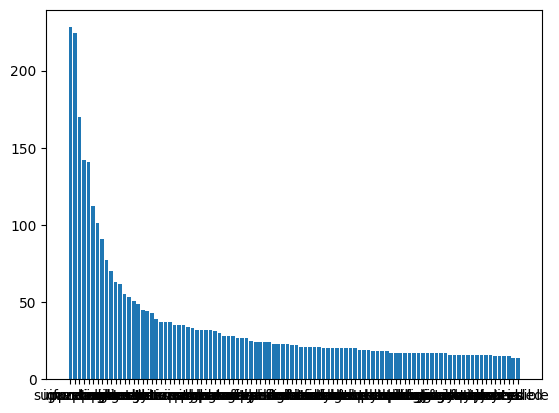

In [61]:
plt.bar([item[0] for item in train_gain_counts.most_common(100)], 
        [item[1] for item in train_gain_counts.most_common(100)])
plt.show()

In [ ]:
# Get all tokens for each model
gain_vocab = list(itertools.chain.from_iterable(eval_gain['response'].apply(tokenize).tolist()))
loss_vocab = list(itertools.chain.from_iterable(eval_loss['response'].apply(tokenize).tolist()))
vocab = list(set(gain_vocab) | set(loss_vocab))

# Get raw counts for each model
gain_vocab_counts = Counter(gain_vocab)
loss_vocab_counts = Counter(loss_vocab)

# Get relative frequencies
gain_vocab_freq = get_rel_freqs(gain_vocab_counts)
loss_vocab_freq = get_rel_freqs(loss_vocab_counts)

df_vocab_freqs = pd.DataFrame({
    'gain': [gain_vocab_freq.get(w,0) for w in vocab],
    'loss': [loss_vocab_freq.get(w,0) for w in vocab]
}, index=vocab)

# Get words with the greatest frequency differences
df_vocab_freqs['difference'] = df_vocab_freqs['gain'] - df_vocab_freqs['loss']

gain_heavy_words = df_vocab_freqs.sort_values(by='difference', ascending=False).head(20)[['difference']]
loss_heavy_words = df_vocab_freqs.sort_values(by='difference', ascending=True).head(20)[['difference']]

In [47]:
# Ignore the most common framing words in the instruction dataset responses
instruction_responses = pd.read_csv('policies_responses.csv')

gain_instruc_vocab = list(itertools.chain.from_iterable(instruction_responses['gain_response'].apply(tokenize).tolist()))
loss_instruc_vocab = list(itertools.chain.from_iterable(instruction_responses['loss_response'].apply(tokenize).tolist()))
instruc_vocab = list(set(gain_instruc_vocab) | set(loss_instruc_vocab))

gain_instruc_vocab_counts = Counter(gain_instruc_vocab)
loss_instruc_vocab_counts = Counter(loss_instruc_vocab)
gain_instruc_vocab_counts

Counter({'supporting': 228,
         'investing': 224,
         'funding': 170,
         'increasing': 142,
         'government': 141,
         'help': 112,
         'provide': 101,
         'public': 91,
         'ensure': 77,
         'reduce': 70,
         'protect': 63,
         'local': 62,
         'energy': 55,
         'health': 53,
         'new': 51,
         'water': 49,
         'clean': 45,
         'allow': 44,
         'carbon': 43,
         'systems': 39,
         'national': 37,
         'citizens': 37,
         'sustainable': 37,
         'use': 35,
         'research': 35,
         'city': 35,
         'make': 34,
         'improve': 33,
         'people': 32,
         'programs': 32,
         'urban': 32,
         'high': 32,
         'community': 31,
         'power': 30,
         'natural': 28,
         'safe': 28,
         'waste': 28,
         'every': 27,
         'need': 27,
         'green': 27,
         'support': 25,
         'children': 24,
         'fami

In [42]:
gain_heavy_words

,difference
investing,0.049851
reduce,0.015624
ensure,0.013998
provide,0.013456
help,0.013095
supporting,0.012643
funding,0.011379
increasing,0.010024
government,0.009934
healthy,0.007767


In [43]:
loss_heavy_words

,difference
failing,-0.038201
invest,-0.026370
without,-0.020771
leave,-0.013998
overlooking,-0.013908
support,-0.012734
lead,-0.012553
nation,-0.010657
neglecting,-0.010024
risks,-0.008941


## Sentiment analysis

In [4]:
analyzer = SentimentIntensityAnalyzer()

gain['sentiment'] = gain['response'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
loss['sentiment'] = loss['response'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

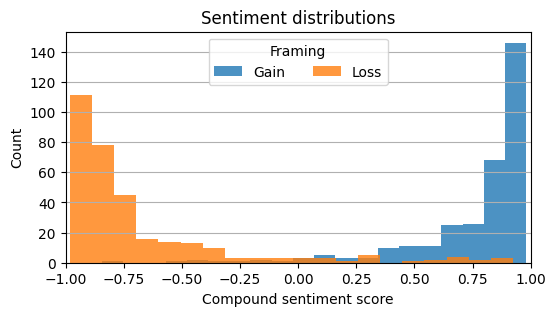

In [5]:
fig, ax = plt.subplots(figsize=(6,3))

ax.hist(gain['sentiment'], bins=20, alpha=0.8, label='Gain')
ax.hist(loss['sentiment'], bins=20, alpha=0.8, label='Loss')

ax.set_title('Sentiment distributions')
ax.set_ylabel('Count')
ax.set_xlabel('Compound sentiment score')
#ax.set_xticks([1.0, 2.0], labels=['Gain', 'Loss'])
ax.set_xlim(-1.0, 1.0)
ax.legend(loc='upper center', ncols=2, title='Framing')
ax.yaxis.grid(True)
plt.show()

## Response length

In [6]:
df['length'] = df['response'].apply(lambda x: len(x.split()))
df.groupby('model')['length'].mean()

model
gain    51.515625
loss    48.762500
Name: length, dtype: float64